In [1]:
import numpy as np
from matplotlib import pyplot as plt
import cv2

In [2]:
def cvt(img):
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

In [3]:
def show(img, cvtB=True):
    if cvtB:
        plt.imshow(cvt(img))
    else:
        plt.imshow(img)
    plt.axis('off')

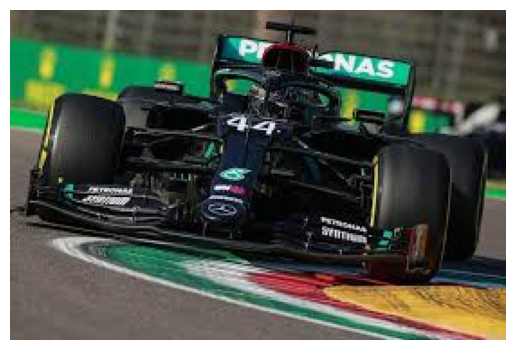

In [4]:
w11 = cv2.imread('w11.jpeg')
show(w11)

### Convert image to HSV, LAB, and YCrCb.

In [5]:
hsv, lab, ycrcb = cv2.cvtColor(w11, cv2.COLOR_BGR2HSV), cv2.cvtColor(w11, cv2.COLOR_BGR2LAB), cv2.cvtColor(w11, cv2.COLOR_BGR2YCrCb)

Text(0.5, 1.0, 'YCRCB Format')

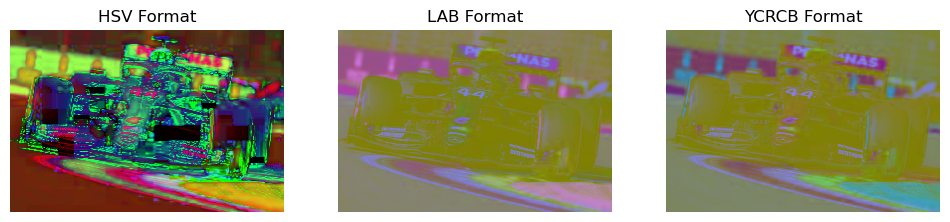

In [6]:
plt.figure(figsize=(12, 10))

plt.subplot(1, 3, 1)
show(hsv)
plt.title('HSV Format')

plt.subplot(1, 3, 2)
show(lab)
plt.title('LAB Format')

plt.subplot(1, 3, 3)
show(ycrcb)
plt.title('YCRCB Format')

###  Isolate and display the Hue channel only.

(np.float64(-0.5), np.float64(274.5), np.float64(182.5), np.float64(-0.5))

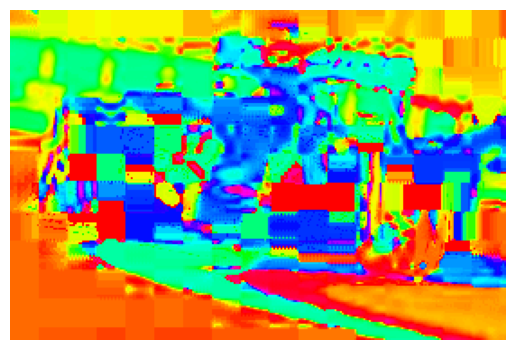

In [7]:
plt.imshow(hsv[:, :, 0], cmap='hsv')
plt.axis('off')

### Apply Gaussian, Median, and Bilateral filtering.

In [8]:
def filters(img):
    return cv2.GaussianBlur(img,(5,5),0), cv2.medianBlur(img,5), cv2.bilateralFilter(img,9,75,75)

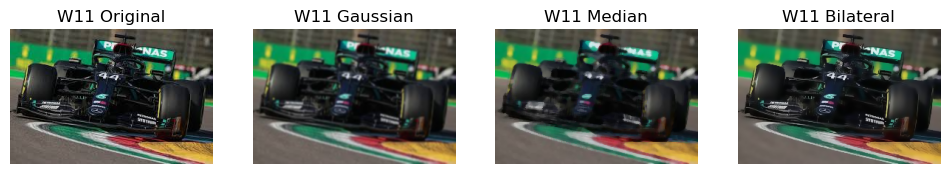

In [9]:
g, m, b = filters(w11)

plt.figure(figsize=(12,6))
for i, (img, title) in enumerate(zip([w11, g, m, b], ['Original','Gaussian','Median','Bilateral'])):
    plt.subplot(1,4,i+1)
    plt.imshow(cvt(img))
    plt.title(f'W11 {title}')
    plt.axis('off')

### Add salt-and-pepper noise and apply filters and show side-by-side filtered and original images.

In [10]:
def sp_noise(img, amount=0.02):
    noisy = img.copy()
    num_salt = np.ceil(amount * img.size * 0.5).astype(int)
    num_pepper = num_salt
    coords_salt = [np.random.randint(0, i-1, num_salt) for i in img.shape[:2]]
    coords_pepper = [np.random.randint(0, i-1, num_pepper) for i in img.shape[:2]]
    noisy[coords_salt[0], coords_salt[1], :] = 255
    noisy[coords_pepper[0], coords_pepper[1], :] = 0
    return noisy

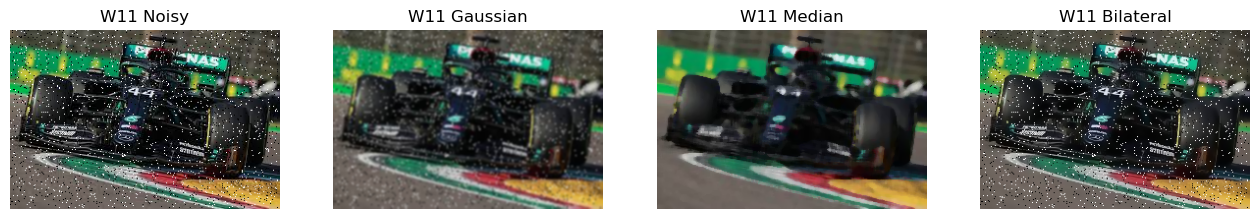

In [11]:
noisy = sp_noise(w11)
g_n, m_n, b_n = filters(noisy)

plt.figure(figsize=(16,4))
for i, (img, title) in enumerate(zip([noisy, g_n, m_n, b_n], ['Noisy','Gaussian','Median','Bilateral'])):
    plt.subplot(1,4,i+1)
    plt.imshow(cvt(img))
    plt.title(f'W11 {title}')
    plt.axis('off')

### Plot histograms of grayscale and BGR images.

In [12]:
def plot_histograms(img, title_prefix):
    colors = ('b', 'g', 'r')
    plt.figure(figsize=(14,5))
    
    # Plot BGR histograms
    plt.subplot(1, 2, 1)
    for i, col in enumerate(colors):
        hist = cv2.calcHist([img], [i], None, [256], [0, 256])
        plt.plot(hist, color=col)
    plt.title(f'{title_prefix} BGR Histogram')
    plt.xlim([0, 256])
    
    # Plot grayscale histogram
    plt.subplot(1, 2, 2)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    hist_gray = cv2.calcHist([gray], [0], None, [256], [0, 256])
    plt.plot(hist_gray, color='black')
    plt.title(f'{title_prefix} Grayscale Histogram')
    plt.xlim([0, 256])

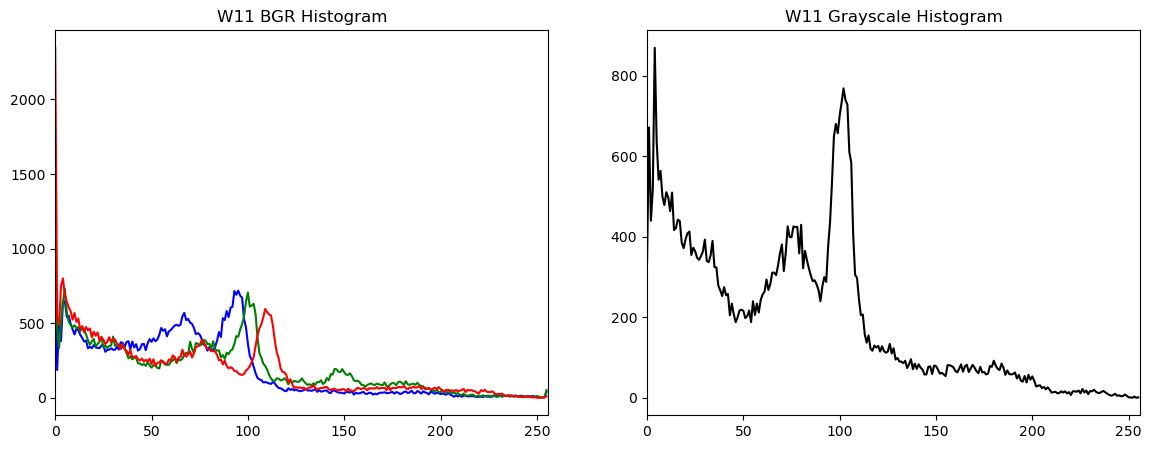

In [13]:
plot_histograms(w11, 'W11')

## Observations:

* Gaussian Blur smooths the image but tends to blur edges and fine details.
* Median Blur is good at removing noise while keeping edges sharper.
* Bilateral Filter preserves edges the best while smoothing other areas.

Overall, Bilateral Filter usually best preserves edges visually.